# Optimizing APLC's with Artisan, Free-range, Hand-rolled, Algorithmic Differentiation

Greetings traveler, if you are here it's because you made some questionable choices in life that lead you to designing coronagraphs. Don't you know that the only way to achieve unaberrated imaging is by blocking all photons?

Regardless, herein lies an attempt at a tutorial to performing the APLC design methodology we wrote in Ashcraft et al. 2025. It leverages the algorithmic differentiation builtin to the `prysm` optical propagation package written by Brandon Dube, and an adaptation of a `vAPPOptimizer` written by Brandon. I also added a minor line of code to make L-BFGS-B happy using `cupy`. 

In [14]:
# import jax.numpy as np
# import numpy as tnp

from prysm.mathops import np, fft, set_backend_to_cupy
import matplotlib.pyplot as plt
import prysm
from tqdm import tqdm
set_backend_to_cupy()

In [2]:
# SIMULATION PARAMETERS
EPD = 24.4381 # milimeters
EFL = EPD * 40 # milimeters
WVL = 0.656   # microns
OS = 8
IMG_NPIX = 256

# Dark Hole
IWA = 2.5
OWA = 12
AZMIN = -89
AZMAX = 89
BANDWIDTH = 10 # percent
NWVLS = 5

In [3]:
# Set up bandpass
half_bw = (BANDWIDTH/2) / 100
band = np.linspace(WVL * (1-half_bw), WVL * (1+half_bw), NWVLS)

# Set the FPM inner working angle to have some margin before the dark hole
FPM_IWA = (1+half_bw) * IWA
FPM_OWA = (1-half_bw) * OWA
print('FPM inner radius = ',FPM_IWA)
print('FPM outer radius = ',FPM_OWA)

FPM inner radius =  2.625
FPM outer radius =  11.399999999999999


Load in the USORT Pupil to have a hexagonally segmented aperture

In [4]:
from astropy.io import fits

# Load Aperture
aperture = np.array(fits.getdata('hex_pupil_amplitude_6510mm_1024pix.fits'))
circle_mask = np.array(fits.getdata('hex_pupil_amplitude_6510mm_1024pix.fits')) 
PUPIL_NPIX = circle_mask.shape[0]

Define the dark hole, focal plane mask, lyot stop

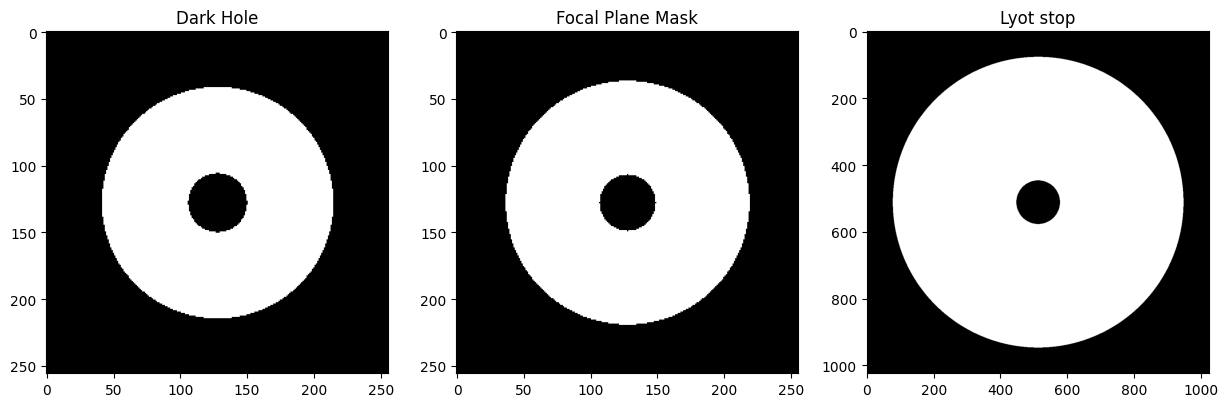

In [ ]:
from prysm.propagation import focus_fixed_sampling, focus_fixed_sampling_backprop
from prysm import coordinates, geometry

img_dx = WVL * (EFL / EPD) / OS
pupil_dx = EPD / PUPIL_NPIX

# now set up the focal plane mask
psf = focus_fixed_sampling(wavefunction=circle_mask,
                           input_dx=pupil_dx,
                           prop_dist=EFL,
                           wavelength=WVL,
                           output_dx=img_dx,
                           output_samples=IMG_NPIX)


lambd = EFL / EPD * WVL  # um
psf_I = np.abs(psf)**2

class ImgSamplingSpec:
    """Specification for image plane sampling."""
    def __init__(self, N, dx, lamD):
        self.N = N
        self.dx = dx
        self.lamD = lamD

    @classmethod
    def from_N_lamD_px_per_lamD(cls, N, lamD, px_per_lamD):
        dx = lamD/px_per_lamD
        return cls(N=N, dx=dx, lamD=lamD)


iss = ImgSamplingSpec(IMG_NPIX, lambd / OS, lambd)  # 10/lambd


# create the core mask
def inner_core_mask(iss, iwa):

    x, y = coordinates.make_xy_grid(iss.N, dx=iss.dx)
    r, t = coordinates.cart_to_polar(x, y)
    iwa = iwa * iss.lamD
    mask = geometry.circle(iwa, r)

    return mask

def knife_edge_mask(iss, iwa):
    x, y = coordinates.make_xy_grid(iss.N, dx=iss.dx)
    iwa = iwa * iss.lamD
    mask = x > iwa

    return mask

def circular_mask(iss, iwa):
    x, y = coordinates.make_xy_grid(iss.N, dx=iss.dx)
    r, t = coordinates.cart_to_polar(x, y)
    iwa = iwa * iss.lamD
    mask = r > iwa

    return mask

def annular_mask(iss, iwa, owa):
    x, y = coordinates.make_xy_grid(iss.N, dx=iss.dx)
    r, t = coordinates.cart_to_polar(x, y)
    iwa = iwa * iss.lamD
    owa = owa * iss.lamD
    mask = r > iwa
    mask[r > owa] = 0

    return mask

def lyot_mask(pupil_npix, pupil_dx, frac, obscuration_ratio=0.1):

    x, y = coordinates.make_xy_grid(pupil_npix, dx=pupil_dx)
    r, t = coordinates.cart_to_polar(x, y)
    rnorm = r / (r.max() * np.sqrt(2))
    ls = np.zeros_like(x)
    ls[rnorm < frac/2] = 1
    ls[rnorm < frac/2 * obscuration_ratio] = 0

    return ls

# add even more margin for the dark hole
focal_plane_mask = annular_mask(iss, FPM_IWA, FPM_OWA)
dh = annular_mask(iss, FPM_IWA * (1+half_bw), FPM_OWA * (1-half_bw))
ls_mask = lyot_mask(circle_mask.shape[0], pupil_dx=pupil_dx, frac=0.85, obscuration_ratio=0.15)

plt.figure(figsize=[15,5])
plt.style.use('default')
plt.subplot(131)
plt.title('Dark Hole')
if np.__name__ == "cupy":
    plt.imshow(dh.get(), cmap='gray')
else:
    plt.imshow(dh, cmap='gray')
plt.subplot(132)
plt.title('Focal Plane Mask')
if np.__name__ == "cupy":
    plt.imshow(focal_plane_mask.get(), cmap='gray')
else:
    plt.imshow(focal_plane_mask, cmap='gray')
plt.subplot(133)
plt.title('Lyot stop')
if np.__name__ == "cupy":
    plt.imshow(ls_mask.get(), cmap='gray')
else:
    plt.imshow(ls_mask, cmap='gray')
plt.show()

Now load in the desired optimizers. The optimizer classes in poi work by summing the cost functions and gradients of the constituent optimizers together in one wrapper that holds all of them, called `APLCWrappper`

In [ ]:
from poi.aplc_design import APLCOptimizer, CoreThroughputOptimizer, APLCWrapper

# define the throughput mask
core_mask = inner_core_mask(iss, 0.7)

# break hermetian symmetry with a little bit of random noise
noisy = np.random.random(circle_mask.shape) * circle_mask / 10000

# Broadband optimization
aplc = APLCOptimizer(amp=circle_mask - noisy,
                        amp_dx=pupil_dx,
                        efl=EFL, 
                        wvl=WVL, 
                        basis=None, 
                        dark_hole=dh,
                        dh_target=0,
                        dh_dx=img_dx,
                        fpm=focal_plane_mask,
                        ls=ls_mask)

core = CoreThroughputOptimizer(amp=circle_mask,
                               amp_dx=pupil_dx,
                               efl=EFL,
                               wvl=WVL,
                               basis=None,
                               window=core_mask,
                               dh_dx=img_dx,
                               fpm=focal_plane_mask,
                               ls=ls_mask,
                               relative_weight=1e-14)

optlist = [aplc, core]
opt_contrast_throughput = APLCWrapper(optlist=optlist)

In [ ]:
from prysm.x.optym import F77LBFGSB
import numpy as tnp
import time

MAX_ITERS = 10000

In [8]:
# starting guess is a filled aperture
x0 = tnp.ones(aplc.amp.shape, dtype=float)[aplc.amp_select.get()]

# initialize the optimizer with box constraints
opt = F77LBFGSB(opt_contrast_throughput.fg, x0,
                memory=10, upper_bounds=tnp.ones(x0.shape),
                lower_bounds=tnp.zeros(x0.shape))
opt.iprint = 1

# some timing
t1 = time.perf_counter()
for _ in tqdm(range(MAX_ITERS)):
    opt.step()

print(time.perf_counter() - t1)

1303.4056630000705


In [9]:
newmask = aplc.amp
newmask[aplc.amp_select] = opt.x

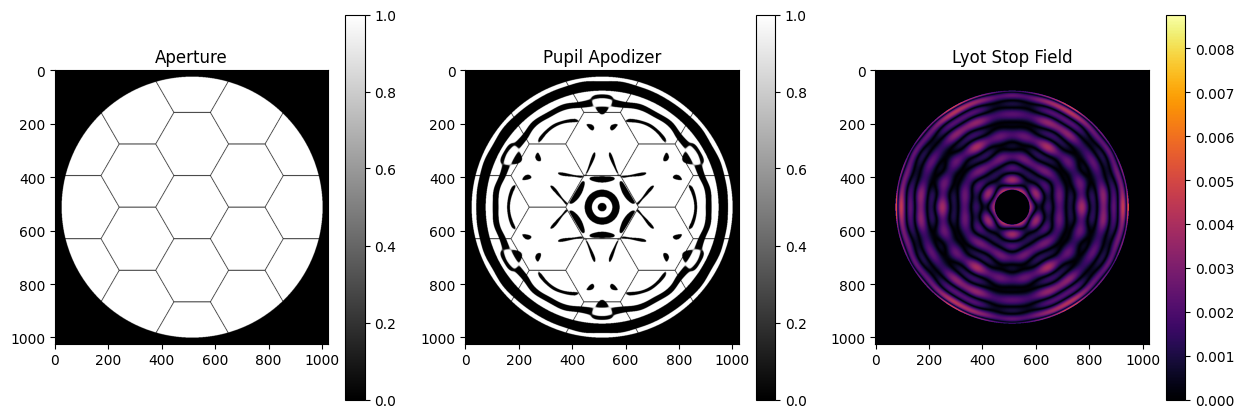

In [10]:
plt.figure(figsize=[15,5])
plt.subplot(131)
plt.title('Aperture')
if np.__name__ == "cupy":
    plt.imshow(aperture.get(),cmap='gray')    
else:
    plt.imshow(aperture, cmap='gray')
plt.colorbar()
plt.subplot(132)
plt.title('Pupil Apodizer')
if np.__name__ == "cupy":
    plt.imshow(newmask.get(),cmap='gray')    
else:
    plt.imshow(newmask, cmap='gray')
plt.colorbar()
plt.subplot(133)
plt.title('Lyot Stop Field')
if np.__name__ == "cupy":
    plt.imshow(ls_mask.get()*(np.abs(aplc.c).get()),cmap='inferno') 
else:
    plt.imshow(ls_mask*(np.abs(aplc.c)),cmap='inferno') 
plt.colorbar()
plt.show()

In [29]:
okabe_colorblind8 = ['#000000', '#E69F00', '#56B4E9', '#009E73',
                     '#F0E442', '#0072B2', '#D55E00', '#CC79A7']

def prop_coro(aplc, fpm, ls, wave=WVL, tilt=0, include_fpm=True):

    pupil_npix = PUPIL_NPIX
    
    # get the tilt phase
    x = np.linspace(-0.5, 0.5, pupil_npix)
    tilt_phase = np.exp(1j * 2 * np.pi * x * tilt)
    
    
    before_fpm = focus_fixed_sampling(
                wavefunction= aplc * tilt_phase,
                input_dx=pupil_dx,
                prop_dist = EFL,
                wavelength= wave,
                output_dx= img_dx,
                output_samples=(IMG_NPIX, IMG_NPIX),
                shift=(0, 0),
                method='mdft')
    
    if include_fpm:
        before_fpm *= fpm

    before_ls = focus_fixed_sampling(
                wavefunction=before_fpm,
                input_dx=img_dx,
                prop_dist = EFL,
                wavelength= wave,
                output_dx= pupil_dx,
                output_samples=(pupil_npix, pupil_npix),
                shift=(0, 0),
                method='mdft')

    coro_img_onax = focus_fixed_sampling(
                wavefunction=before_ls * ls,
                input_dx=pupil_dx,
                prop_dist = EFL,
                wavelength= wave,
                output_dx= img_dx,
                output_samples=(IMG_NPIX, IMG_NPIX),
                shift=(0, 0),
                method='mdft')
    
    return before_fpm, before_ls, coro_img_onax

In [25]:
fx = np.linspace(-IMG_NPIX / (2 * OS), IMG_NPIX / (2 * OS), IMG_NPIX)
fx, fy = np.meshgrid(fx, fx)

# 14 mins uh oh
from matplotlib.colors import LogNorm
from tqdm import tqdm
tilt_lds = np.arange(0, 12, 0.25)
core_size = 0.7
throughput = []

throughput_07 = []

for i, ld in tqdm(enumerate(tilt_lds)):

    before, ls, coro = prop_coro(newmask, focal_plane_mask, ls_mask, tilt=ld)
    
    if i == 0:
        coro_intensity = np.abs(coro)**2
        before_fpm_intensity = np.abs(before)**2
        contrast_onax_3p5 = coro_intensity / before_fpm_intensity.max()
    
    before_I = np.sum(np.abs(before)**2)
    coro_I = np.abs(coro)**2
    throughput.append(np.sum(coro_I) / np.sum(aperture))
    
    # get value in 0.7 L/D (recall 1/OS is pixelscale in L/D)
    fx = np.linspace(-IMG_NPIX / (2 * OS), IMG_NPIX / (2 * OS), IMG_NPIX)
    fx, fy = np.meshgrid(fx, fx)
    fx += ld
    rx = np.sqrt(fx**2 + fy**2)
    mask = np.zeros_like(rx, dtype=int)
    mask[rx < core_size] = 1
    
    value_in_aperture = np.sum(coro_I[mask==1])
    throughput_07.append(value_in_aperture / np.sum(aperture))

48it [00:00, 78.36it/s]


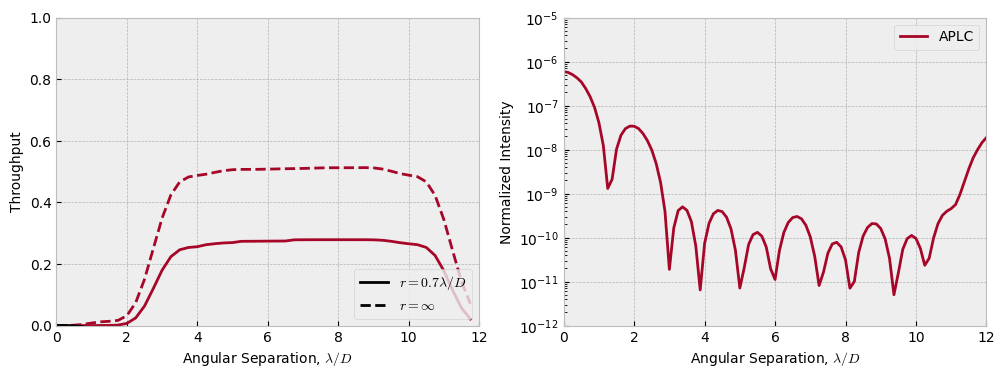

In [26]:
# get the bmh colors
plt.style.use("bmh")
colors = plt.rcParams['axes.prop_cycle'].by_key()['color'][1:]

def radial_profile(data, center=[int(IMG_NPIX/2),int(IMG_NPIX/2)]):
    y, x = tnp.indices((data.shape))
    r = tnp.sqrt((x - center[0])**2 + (y - center[1])**2)
    r = r.astype(int)

    tbin = tnp.bincount(r.ravel(), data.ravel())
    nr = tnp.bincount(r.ravel())
    radialprofile = tbin / nr
    return radialprofile

plt.figure(figsize=[12,4])
plt.subplot(121)
if np.__name__ == "cupy":
    plt.plot(tilt_lds.get(), np.array(throughput).get(), linestyle='dashed', color=colors[0])
    plt.plot(tilt_lds.get(), np.array(throughput_07).get(), linestyle='solid', color=colors[0])
    plt.plot(tilt_lds.get(), -np.array(throughput).get(), linestyle='solid', color='black', label=r'$r = 0.7\lambda / D$')
    plt.plot(tilt_lds.get(), -np.array(throughput).get(), linestyle='dashed', color='black', label=r'$r = \infty$')
else:
    plt.plot(tilt_lds, np.array(throughput), linestyle='dashed', color=colors[0])
    plt.plot(tilt_lds, np.array(throughput_07), linestyle='solid', color=colors[0])
    plt.plot(tilt_lds, -np.array(throughput), linestyle='solid', color='black', label=r'$r = 0.7\lambda / D$')
# plt.vlines(3.5,-1,1, color=colors[0], alpha=0.5)
# plt.vlines(2.5,-1,1, color=colors[1], alpha=0.5)
plt.xlabel('Angular Separation, '+r'$\lambda / D$')
# plt.text(3, 0.15, 'APLC-3.5 IWA', rotation=90, color=colors[0], fontweight='bold')
# plt.text(2, 0.15, 'APLC-2.5 IWA', rotation=90, color=colors[1], fontweight='bold')
plt.ylabel('Throughput')
plt.legend(loc='lower right')
plt.ylim(0,1)
plt.xlim(0,12)

# get radial
radial_profile_3p5 = radial_profile(contrast_onax_3p5.get())
x_axis = tnp.ones_like(radial_profile_3p5) # just get array size
dx_ld = 1/8
x_ticks = [dx_ld*i for i in range(len(x_axis))]
x_ticks = tnp.array(x_ticks)

plt.subplot(122)
plt.plot(x_ticks, radial_profile_3p5, color=colors[0], label='APLC')
# plt.vlines(3.5,0,1, color=colors[0], alpha=0.5, linestyle='solid')
# plt.vlines(2.5,0,1, color=colors[1], alpha=0.5, linestyle='solid')
plt.xlabel('Angular Separation, '+r'$\lambda / D$')
plt.xlim(0,12)
plt.ylim(1e-12, 1e-5)
plt.yscale('log')
plt.ylabel('Normalized Intensity')
plt.legend()
plt.savefig('coronagraph_throughput_and_contrast.pdf')
plt.show()

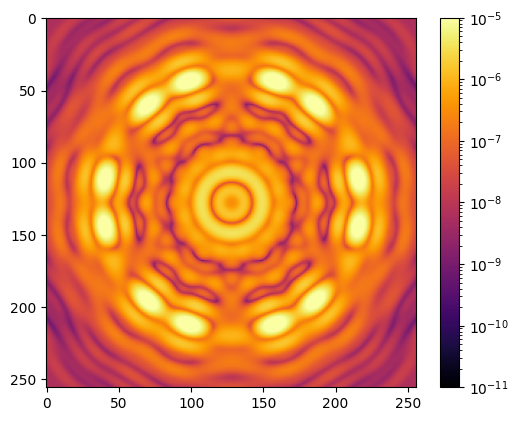

In [41]:
psf = 0
psf_norm = 0

for wvl in band:

    before_fpm, before_ls, coro = prop_coro(aplc.aplc, aplc.fpm, aplc.ls, wave=wvl)
    psf += np.abs(coro)**2 / len(band)

    before_fpm, before_ls, coro = prop_coro(aplc.aplc, aplc.fpm, aplc.ls, wave=wvl, include_fpm=False)
    psf_norm += np.abs(coro)**2 / len(band)

psf_broadband = psf.get()
psf_broadband /= psf_norm.get().max()

plt.figure()
plt.imshow(psf_broadband, cmap="inferno", norm=LogNorm(vmin=1e-11, vmax=1e-5))
plt.colorbar()
plt.show()


In [28]:
band

array([0.6232, 0.6396, 0.656 , 0.6724, 0.6888])